In [1]:


import torch 
import torch.nn as nn
import torch.optim as optim

from torchvision.datasets import MNIST
from torchvision import transforms
from torch.utils.data import DataLoader
import matplotlib.pyplot as plt
import numpy as np


In [2]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

Using device: cuda


Epoch 1/5, Loss: 0.33617750096168597
Epoch 2/5, Loss: 0.14021794223633688
Epoch 3/5, Loss: 0.09364467845665717
Epoch 4/5, Loss: 0.06971870544778584
Epoch 5/5, Loss: 0.05543250229824255
Accuracy: 97.22%
Model saved to mnist_model.pth


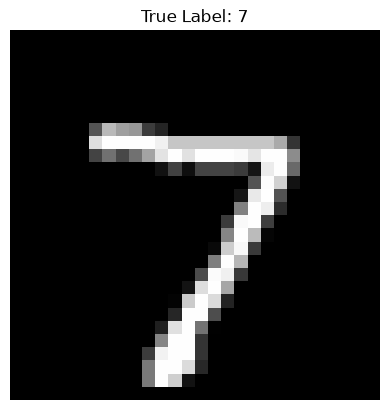

Predicted Label: 7
True Label: 7


<All keys matched successfully>

In [ ]:
# converts each PIL image to a tensor with pixel values scaled to [0, 1]
transform = transforms.ToTensor()

# download (if needed) and load the MNIST train/test splits
train_dataset = MNIST(root='./data',
                       train=True, 
                       download=True,
                         transform=transform)

test_dataset = MNIST(root='./data',
                      train=False,
                      download=True,
                      transform=transform)

# DataLoader yields batches of (image, label) pairs (batch_size, 1, 28, 28) and (batch_size,) respectively
train_loader = DataLoader(dataset=train_dataset,
                            batch_size=64,
                            shuffle=True)          # shuffle for training so batches vary each epoch

test_loader = DataLoader(dataset=test_dataset,
                           batch_size=64,
                           shuffle=False)           # no need to shuffle when evaluating

# simple fully-connected network: 784 -> 128 -> 64 -> 10
class DigitModel(nn.Module):
    def __init__(self):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(28*28, 128),  # flattened 28x28 image as input
            nn.ReLU(),
            nn.Linear(128, 64),
            nn.ReLU(),
            nn.Linear(64, 10)       # 10 output logits, one per digit class
        )

    def forward(self, x):
        return self.net(x)

model = DigitModel().to(device) # move model to GPU if available

loss_fn = nn.CrossEntropyLoss()                     # applies softmax + negative log-likelihood internally
optimizer = optim.Adam(model.parameters(), lr=0.001)

epochs = 5

# training loop
for epoch in range(epochs):
    model.train()
    total_loss = 0

    for image, labels in train_loader:
        image = image.view(image.size(0), -1).to(device)  # flatten (batch, 1, 28, 28) -> (batch, 784)
        labels = labels.to(device)

        optimizer.zero_grad()          # clear gradients from the previous step
        output = model(image)          # forward pass
        loss = loss_fn(output, labels)
        loss.backward()                # backpropagate
        optimizer.step()               # update weights

        total_loss += loss.item()

    print(f"Epoch {epoch+1}/{epochs}, Loss: {total_loss/len(train_loader)}")

# evaluate accuracy on the held-out test set
model.eval()
correct = 0
total = 0

with torch.no_grad():                  # no need to track gradients during evaluation
    for image, labels in test_loader:
        image = image.view(image.size(0), -1).to(device)
        labels = labels.to(device)

        output = model(image)
        predicted = output.argmax(dim=1)   # class with the highest logit
        total += labels.size(0)
        correct += (predicted == labels).sum().item()

print(f"Accuracy: {100 * correct / total}%")


torch.save(model.state_dict(), "mnist_model.pth") # save the model's parameters to a file
print("Model saved to mnist_model.pth")

# pick one test image and show it alongside its true label
index = 0
image, true_label = test_dataset[index]


plt.imshow(image.squeeze(), cmap='gray')
plt.title(f"True Label: {true_label}")
plt.axis('off')
plt.show()

image_flat = image.view(1, -1).to(device) # flatten the image to (1, 784) and move to device

# run inference on that single image
with torch.no_grad():
    output = model(image_flat)
    predicted_label = output.argmax(dim=1).item()

print(f"Predicted Label: {predicted_label}")
print(f"True Label: {true_label}")

# reload the saved weights from disk to confirm they were stored correctly
state_dict = torch.load("mnist_model.pth", map_location=device)
model.load_state_dict(state_dict)